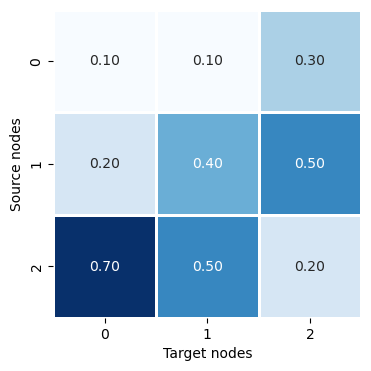

In [9]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

a = np.array([
    [0.1, 0.1, 0.3],
    [0.2, 0.4, 0.5],
    [0.7, 0.5, 0.2]
])

plt.figure(figsize=(5, 4))

sns.heatmap(
    a,
    annot=True,          # show values in cells
    fmt=".2f",           # number formatting
    cmap="Blues",        # blue -> white colormap
    cbar=False,
    square=True,
    linewidths=1,
    linecolor="white"
)
plt.xlabel('Target nodes')
plt.ylabel('Source nodes')
plt.show()

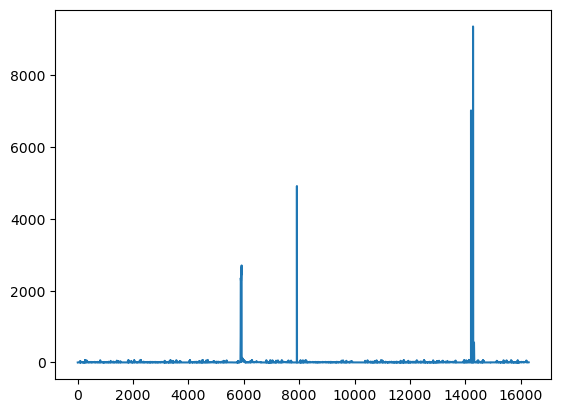

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

labels = pd.read_csv('labels_WADI.csv')
scores = labels['total_topk_err_scores']
true = labels['Ground truth labels']
pred = labels['Predicted labels']

correct_mask = (true == pred)

non_glitch_mask = (true == 1)

non_glitch_scores = scores[non_glitch_mask]
glitch_scores = scores[-non_glitch_mask]


#plt.hist(glitch_scores)
plt.plot(range(0,len(non_glitch_scores)), non_glitch_scores)
#plt.ylim(0,65)
plt.savefig('__test.png')


In [2]:
def get_attack_interval(attack): 
    heads = []
    tails = []
    for i in range(len(attack)):
        if attack[i] == 0:
            if attack[i-1] == 1:
                heads.append(i)
            
            if i < len(attack)-1 and attack[i+1] == 1:
                tails.append(i)
            elif i == len(attack)-1:
                tails.append(i)
    res = []
    for i in range(len(heads)):
        res.append((heads[i], tails[i]))
    # print(heads, tails)
    return res

res = get_attack_interval(true)

In [3]:
start = np.zeros(len(res))
end = np.zeros(len(res))
for i in range(len(res)):
    start[i] = int(res[i][0])
    end[i] = int(res[i][1])
    

In [4]:
print(start)
print(end)

[  506.  5901.  6086.  6300.  7073.  7485.  8516. 10841. 14726. 14863.
 14970. 15110. 15212. 16355.]
[  654.  5958.  6258.  6383.  7138.  7553.  8572. 10859. 14733. 14942.
 15036. 15144. 15268. 16416.]


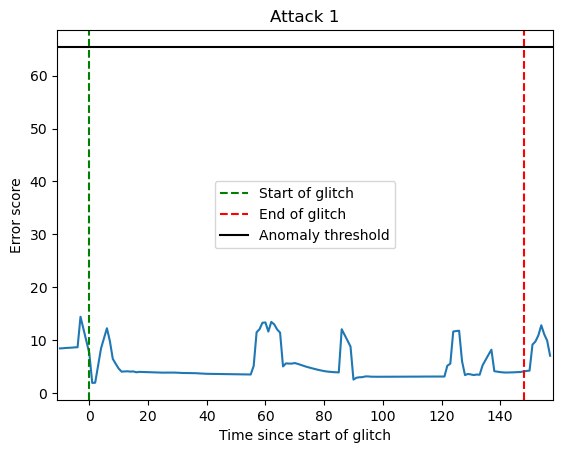

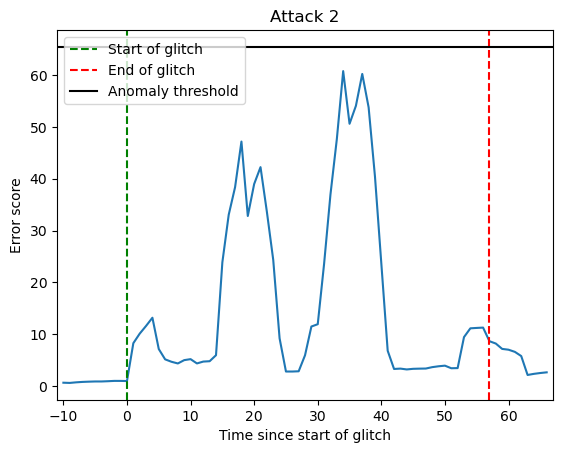

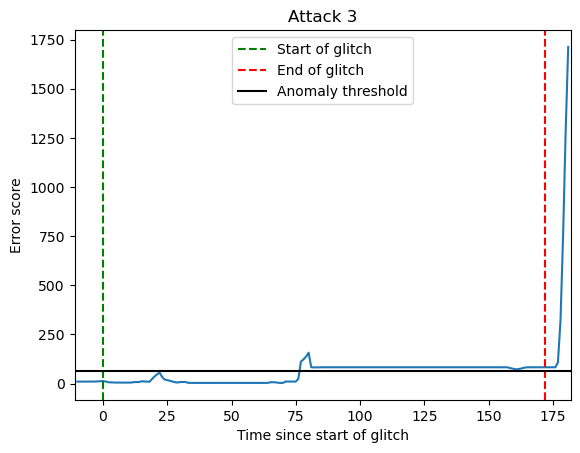

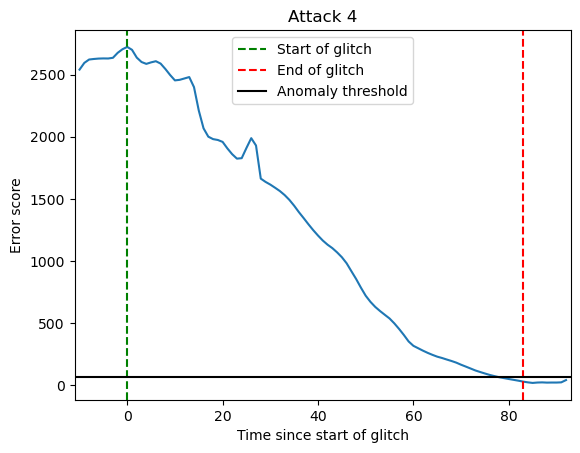

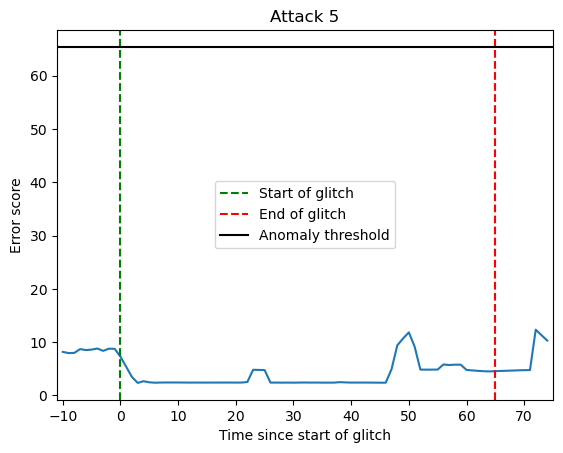

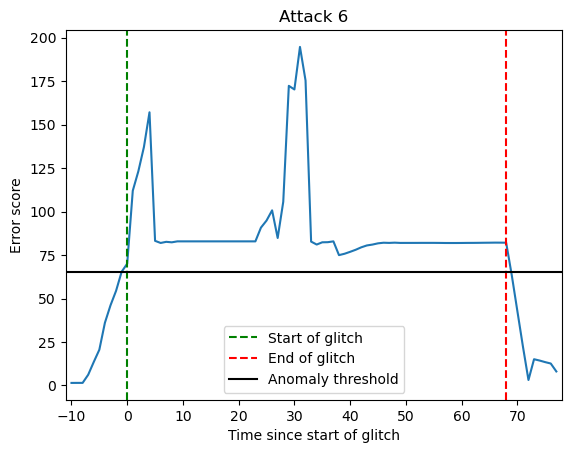

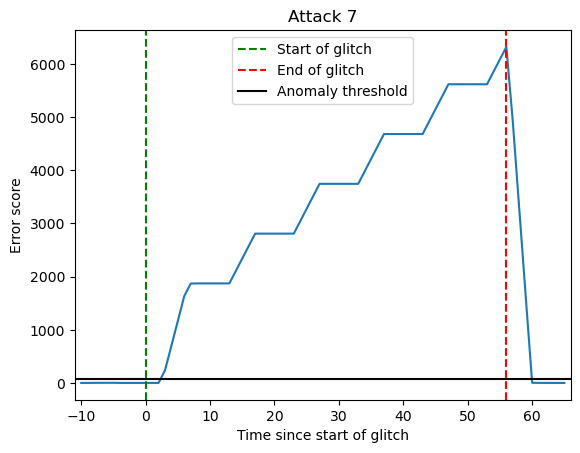

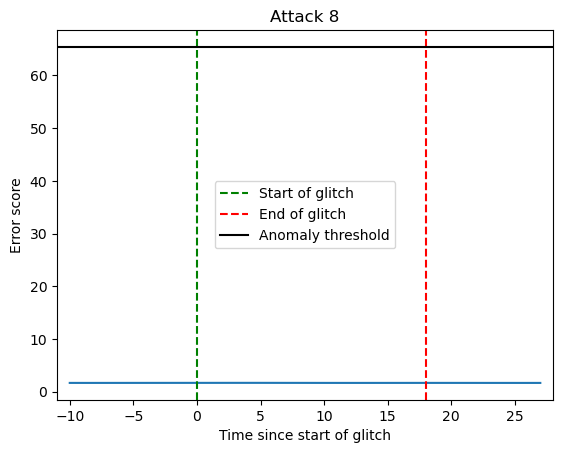

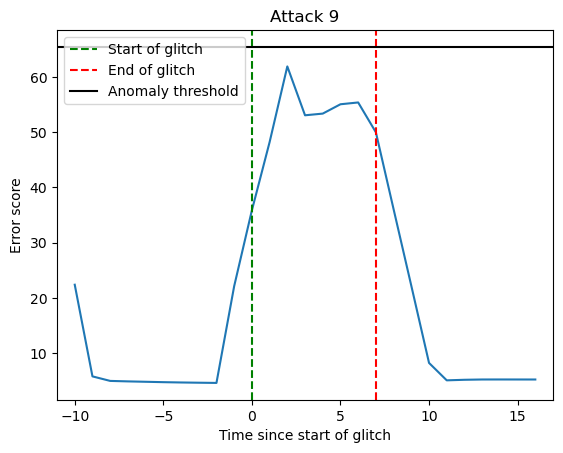

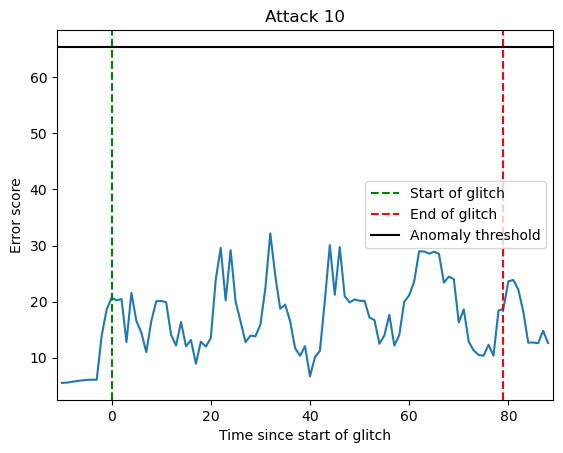

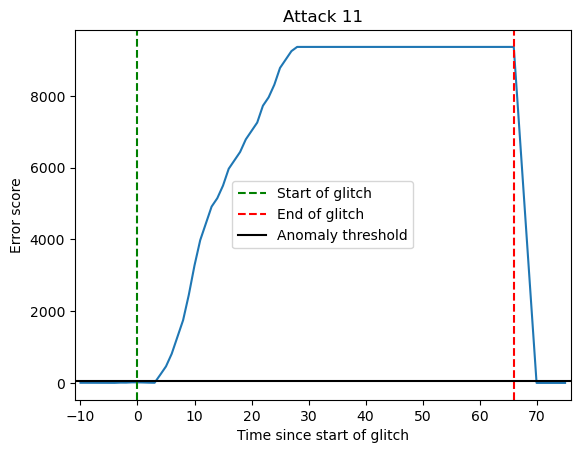

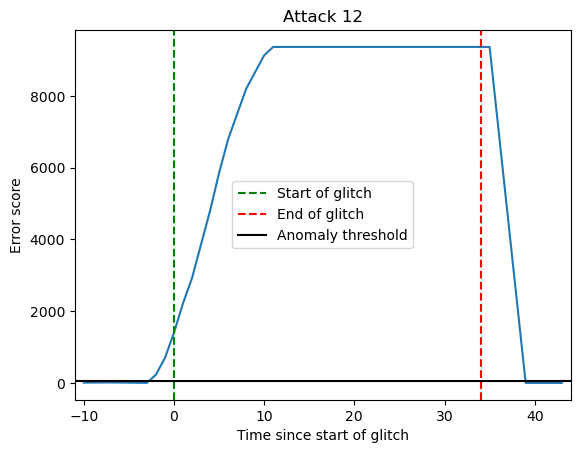

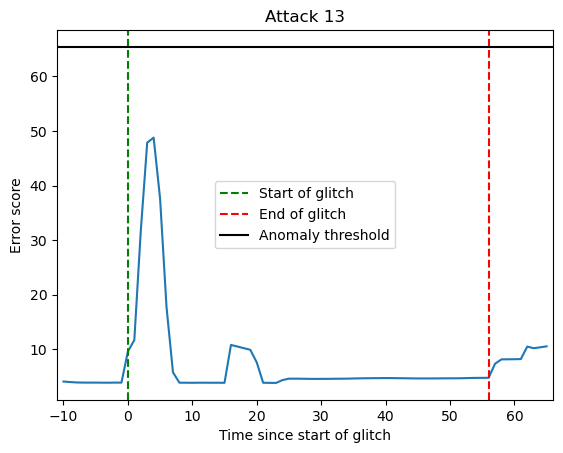

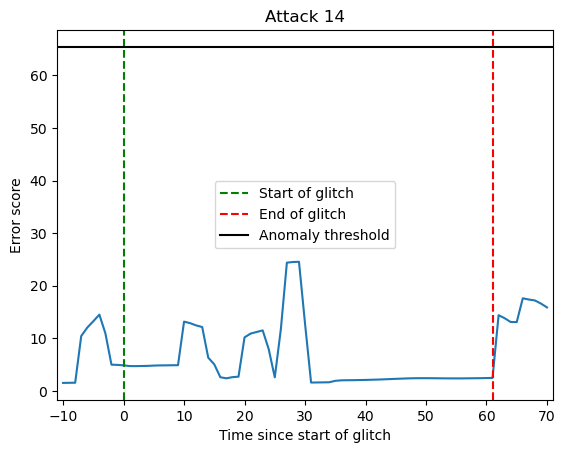

<Figure size 640x480 with 0 Axes>

In [5]:
for i in range(len(start)):
    glitch_range = scores[int(start[i])-10:int(end[i])+10]
    plt.ylabel('Error score')
    plt.xlabel('Time since start of glitch')
    plt.title(f'Attack {i+1}')
    plt.plot(range(-10,len(glitch_range)-10), glitch_range)
    plt.axvline(x = 0, color = 'g', label = 'Start of glitch', linestyle = '--' )
    plt.axvline(x = len(glitch_range)-20, color = 'r', label = 'End of glitch', linestyle = '--' )
    plt.axhline(y = 65.412096, color = 'black', label = 'Anomaly threshold')
    plt.legend()
    plt.xlim(-11, len(glitch_range)-10)
    plt.figure()


In [6]:
import torch
values = torch.load('values_WADI.pt', map_location='cpu')

pred_values = values[0]
true_values = values[1]

print(pred_values.shape)
print(true_values.shape)


torch.Size([17275, 127])
torch.Size([17275, 127])


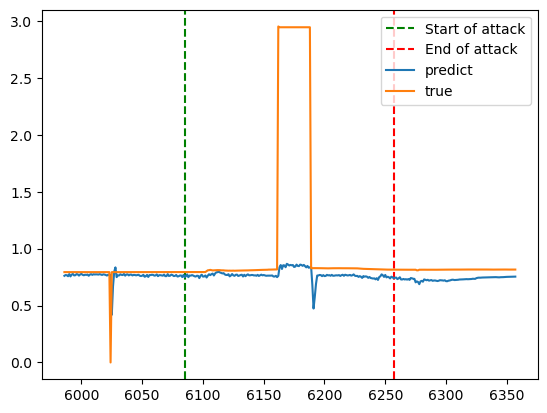

In [7]:
channel = 0
attack_id = 3
margin = 100
a = pred_values[int(start[attack_id - 1]) - margin:int(end[attack_id - 1]) + margin,channel]
b = true_values[int(start[attack_id - 1]) - margin:int(end[attack_id - 1]) + margin,channel]
plt.axvline(x = int(start[attack_id - 1]) - 1, color = 'g', label = 'Start of attack', linestyle = '--' )
plt.axvline(x = int(end[attack_id - 1]) - 1, color = 'r', label = 'End of attack', linestyle = '--' )
plt.plot(range(int(start[attack_id - 1]) - margin,int(end[attack_id - 1]) + margin), a, label = 'predict')
plt.plot(range(int(start[attack_id - 1]) - margin,int(end[attack_id - 1]) + margin), b, label = 'true')
plt.legend()
plt.show()

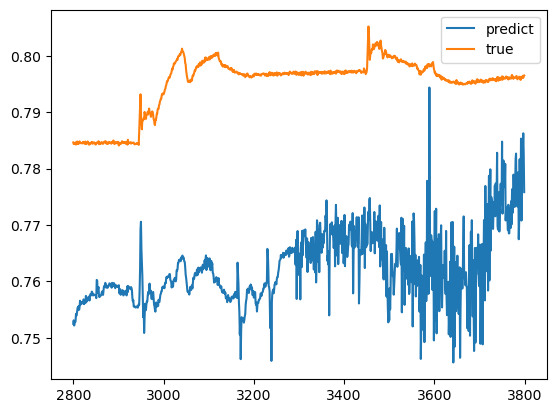

In [8]:
a = pred_values[2800: 3800,channel]
b = true_values[2800: 3800,channel]
plt.plot(range(2800,3800), a, label = 'predict')
plt.plot(range(2800,3800), b, label = 'true')
plt.legend()
plt.show()